In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("SampleSuperstore.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (9994, 13)


In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
print(df.columns.tolist())

['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


In [5]:
print(df.isnull().sum())

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [6]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


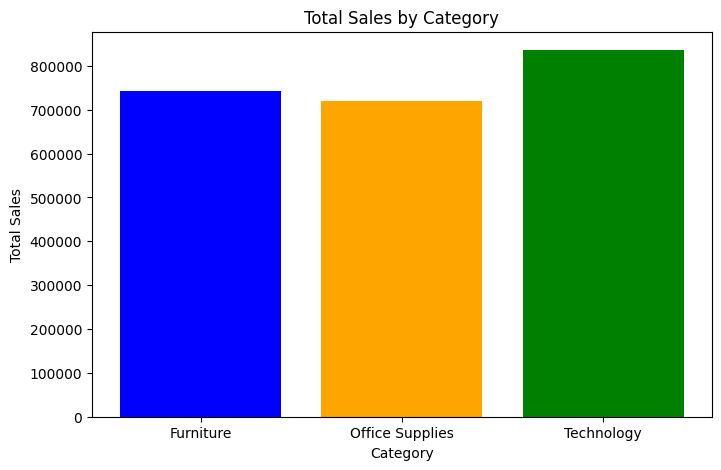

In [7]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values, color=["blue", "orange", "green"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

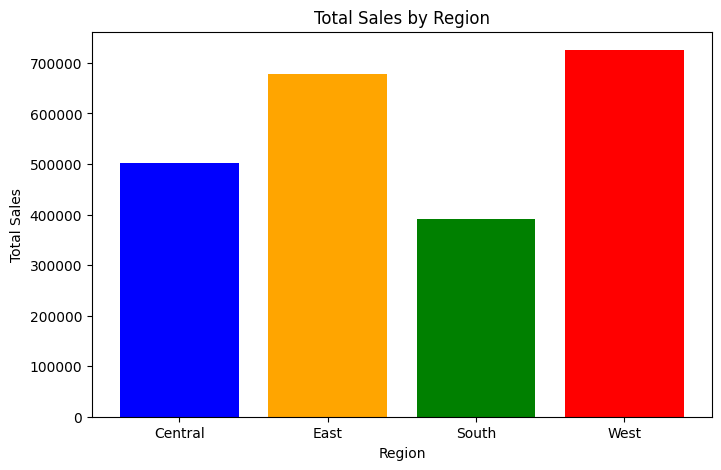

In [8]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(region_sales.index, region_sales.values, color=["blue", "orange", "green", "red"])
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

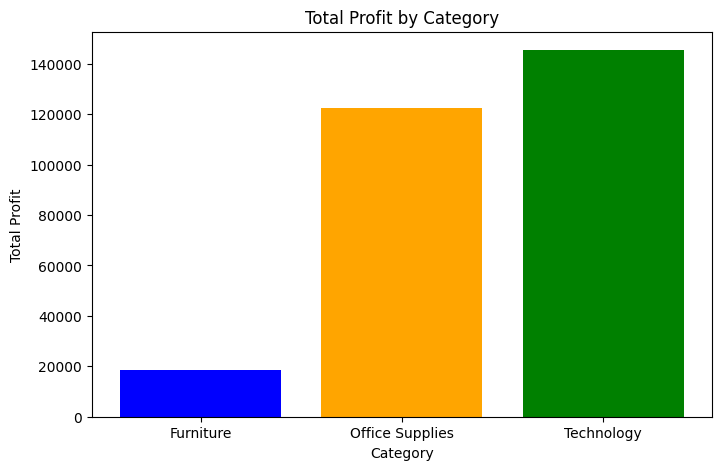

In [9]:
category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
plt.bar(category_profit.index, category_profit.values, color=["blue", "orange", "green"])
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

In [10]:
# Convert Order Date to a date format Python understands
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract the month and year
df["Month-Year"] = df["Order Date"].dt.to_period("M")

# Add up sales for each month
monthly_sales = df.groupby("Month-Year")["Sales"].sum()

# Plot it
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, color="blue", marker="o")
plt.title("Monthly Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'Order Date'

In [11]:
print(df.columns.tolist())

['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


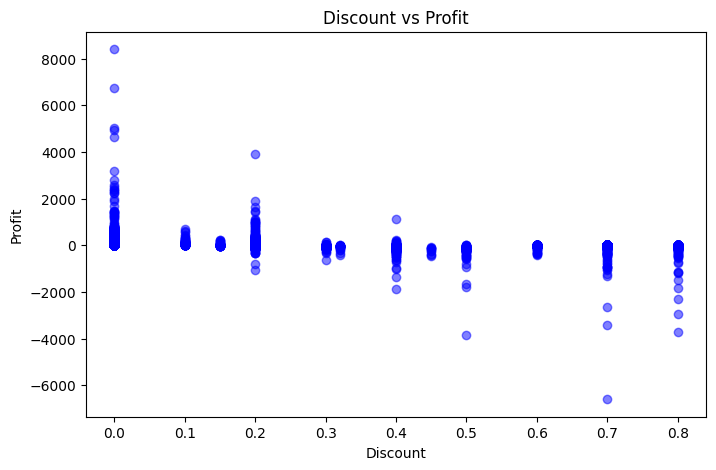

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit"], color="blue", alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Step 1: Pick our input columns and what we want to predict
X = df[["Sales", "Quantity", "Discount"]]
y = df["Profit"]

# Step 2: Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
# Step 4: Test the model
y_pred = model.predict(X_test)

# Step 5: Check how accurate it is
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", round(mae, 2))

Mean Absolute Error: 69.77


In [15]:
print("Average Profit:", round(df["Profit"].mean(), 2))
print("Highest Profit:", round(df["Profit"].max(), 2))
print("Lowest Profit:", round(df["Profit"].min(), 2))

Average Profit: 28.66
Highest Profit: 8399.98
Lowest Profit: -6599.98


In [16]:
from sklearn.ensemble import RandomForestRegressor

# A more powerful model
better_model = RandomForestRegressor(n_estimators=100, random_state=42)
better_model.fit(X_train, y_train)

# Test it
better_pred = better_model.predict(X_test)
better_mae = mean_absolute_error(y_test, better_pred)
print("Improved Model Error:", round(better_mae, 2))

Improved Model Error: 32.6


In [17]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gradient_model.fit(X_train, y_train)

gradient_pred = gradient_model.predict(X_test)
gradient_mae = mean_absolute_error(y_test, gradient_pred)
print("Gradient Boosting Error:", round(gradient_mae, 2))

Gradient Boosting Error: 38.01


In [18]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
print("XGBoost Error:", round(xgb_mae, 2))

XGBoost Error: 36.22


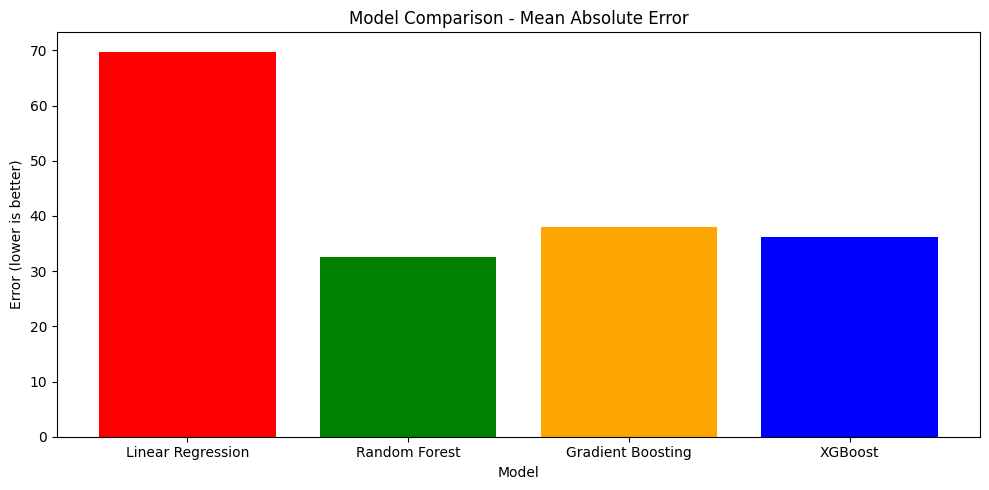

In [19]:
models = ["Linear Regression", "Random Forest", "Gradient Boosting", "XGBoost"]
errors = [69.77, 32.60, 38.01, 36.22]

plt.figure(figsize=(10,5))
plt.bar(models, errors, color=["red", "green", "orange", "blue"])
plt.title("Model Comparison - Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("Error (lower is better)")
plt.tight_layout()
plt.show()

In [20]:
print("=" * 50)
print("BUSINESS FORECAST FROM MY ANALYSIS")
print("=" * 50)
print()
print("1. Technology has the highest total sales")
print()
print("2. West region generates the most revenue")
print()
print("3. Higher discounts directly cause lower profits")
print("   - Business should reduce unnecessary discounts")
print()
print("4. Best prediction model: Random Forest")
print("   - Average prediction error: $32.60")
print()
print("5. Profit ranges from -$6,599 to +$8,399")
print("   - Some orders are losing money!")
print("   - Business should investigate loss-making orders")

BUSINESS FORECAST FROM MY ANALYSIS

1. Technology has the highest total sales

2. West region generates the most revenue

3. Higher discounts directly cause lower profits
   - Business should reduce unnecessary discounts

4. Best prediction model: Random Forest
   - Average prediction error: $32.60

5. Profit ranges from -$6,599 to +$8,399
   - Some orders are losing money!
   - Business should investigate loss-making orders


In [22]:
print("=" * 50)
print("BUSINESS INSIGHTS FROM OUR ANALYSIS")
print("=" * 50)
print()
print("1. Technology has the highest total sales")
print()
print("2. West region generates the most revenue")
print()
print("3. Higher discounts directly cause lower profits")
print("   - Business should reduce unnecessary discounts")
print()
print("4. Best prediction model: Random Forest")
print("   - Average prediction error: $32.60")
print()
print("5. Profit ranges from -$6,599 to +$8,399")
print("   - Some orders are losing money!")
print("   - Business should investigate loss-making orders")
print("5. CHALLENGES FACED WHILE DOING THE TASK")
print("   - Unfortunately there was no date column in the dataset i downloaded from kaggle.com and i didn't realize it until i was too far so i couldn't do time based engineering and the data had clean data set with zero missing data")
print("   - I also had to explore other forecasting methods just to get the most efficient model error which i got from random forest as the most effective")

BUSINESS INSIGHTS FROM OUR ANALYSIS

1. Technology has the highest total sales

2. West region generates the most revenue

3. Higher discounts directly cause lower profits
   - Business should reduce unnecessary discounts

4. Best prediction model: Random Forest
   - Average prediction error: $32.60

5. Profit ranges from -$6,599 to +$8,399
   - Some orders are losing money!
   - Business should investigate loss-making orders
5. CHALLENGES FACED WHILE DOING THE TASK
   - Unfortunately there was no date column in the dataset i downloaded from kaggle.com and i didn't realize it until i was too far so i couldn't do time based engineering and the data had clean data set with zero missing data
   - I also had to explore other forecasting methods just to get the most efficient model error which i got from random forest as the most effective


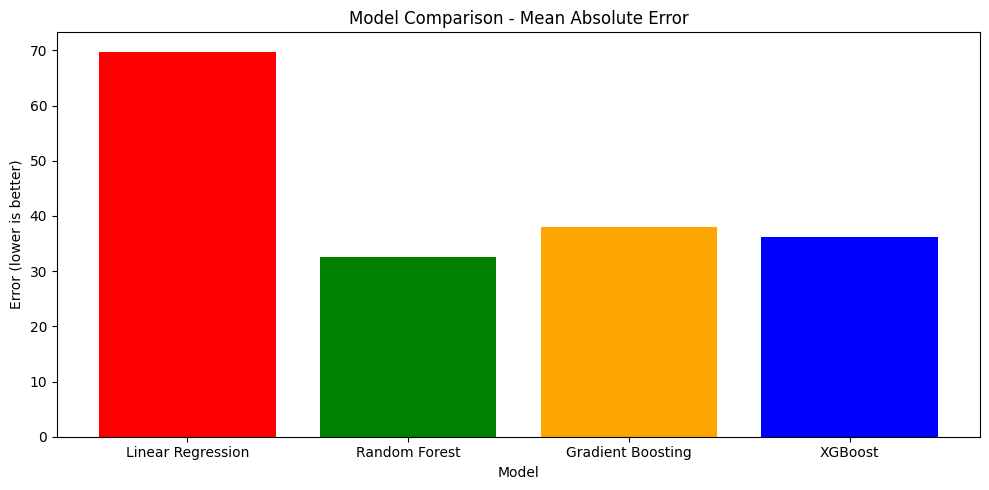

Chart saved successfully!


In [23]:
models = ["Linear Regression", "Random Forest", "Gradient Boosting", "XGBoost"]
errors = [69.77, 32.60, 38.01, 36.22]

plt.figure(figsize=(10,5))
plt.bar(models, errors, color=["red", "green", "orange", "blue"])
plt.title("Model Comparison - Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("Error (lower is better)")
plt.tight_layout()

# This line saves it as an image
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved successfully!")